# Kernel Trick Demo for SVM (2D → Nonlinear)

This notebook gives you **slide-ready, interactive** cells to teach the kernel trick:

1. **Why linear SVMs fail** on nonlinear 2D data (moons/circles).
2. **RBF kernel** decision boundaries vs a linear one.
3. **Animation**: sweep \(\gamma\) for RBF to show how the boundary becomes wiggly/overfit when \(\gamma\) is too large.
4. **Explicit polynomial map** example: a simple degree-2 feature map that makes a ring separable by a plane in 3D.
5. **Tuning**: quick `GridSearchCV` snippet for (`C`, `gamma`).

Everything is kept **2D** for intuition; we only show higher-dimensional mapping in one concrete example (degree-2 polynomial) to make the trick tangible.

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D proj)

np.random.seed(7)
plt.rcParams["figure.figsize"] = (6, 5)


## 1) Make nonlinear 2D datasets
- Two-moons: classic non-separable by a straight line.
- Concentric circles: linear SVM fails; polynomial/RBF helps.

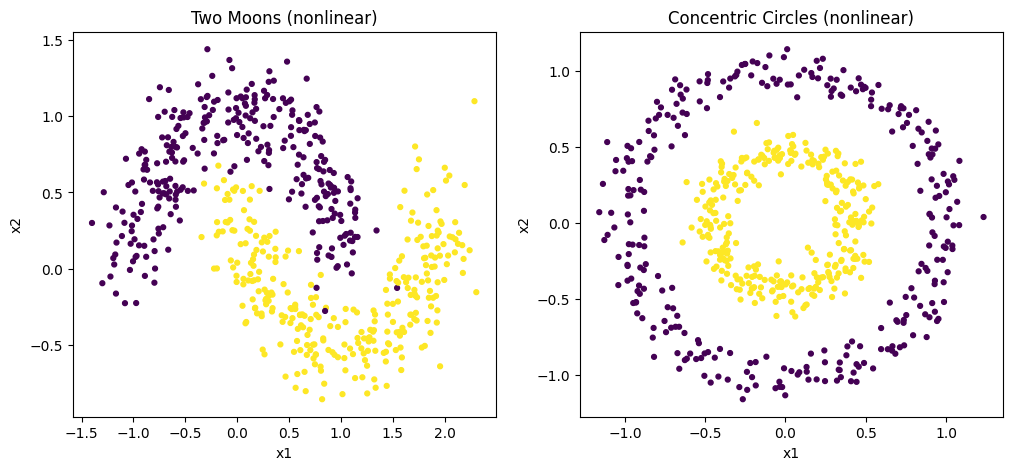

In [ ]:
X_moons, y_moons = make_moons(n_samples=600, noise=0.18, random_state=7)
X_circ, y_circ = make_circles(n_samples=600, factor=0.45, noise=0.08, random_state=7)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(X_moons[:,0], X_moons[:,1], c=y_moons, s=12)
ax[0].set_title("Two Moons (nonlinear)"); ax[0].set_xlabel("x1"); ax[0].set_ylabel("x2")
ax[1].scatter(X_circ[:,0], X_circ[:,1], c=y_circ, s=12)
ax[1].set_title("Concentric Circles (nonlinear)"); ax[1].set_xlabel("x1"); ax[1].set_ylabel("x2")
plt.show()


## 2) Helper: plot decision regions for a trained classifier
We keep this simple and **2D**. No seaborn, just matplotlib.

In [ ]:
def plot_decision_regions(clf, X, y, title=""):
    x1min, x1max = X[:,0].min()-0.5, X[:,0].max()+0.5
    x2min, x2max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1min, x1max, 400),
                           np.linspace(x2min, x2max, 400))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = clf.predict(grid).reshape(xx1.shape)
    plt.figure()
    plt.contourf(xx1, xx2, Z, alpha=0.25)
    plt.scatter(X[:,0], X[:,1], c=y, s=12, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()


## 3) Linear vs RBF SVM on nonlinear data
Observe how linear SVM cannot carve the non-linear boundary, while RBF can.

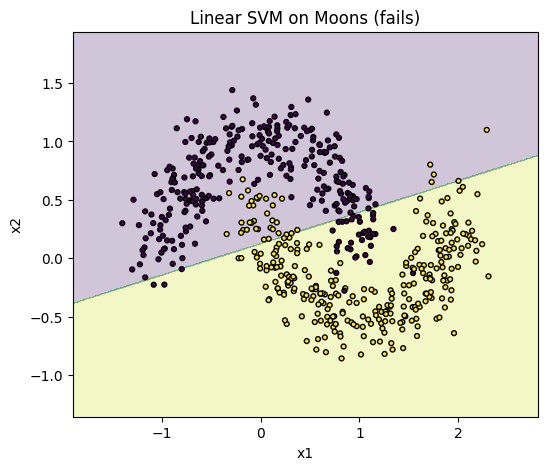

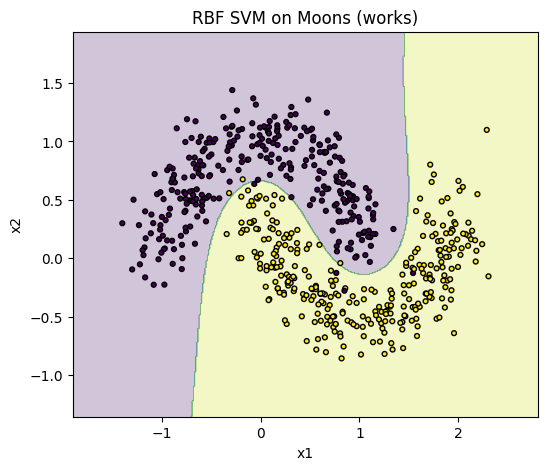

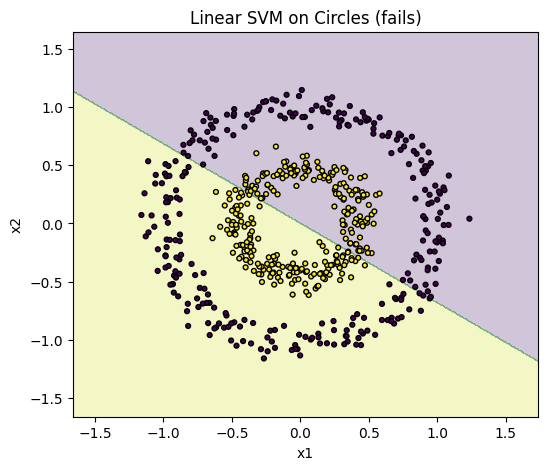

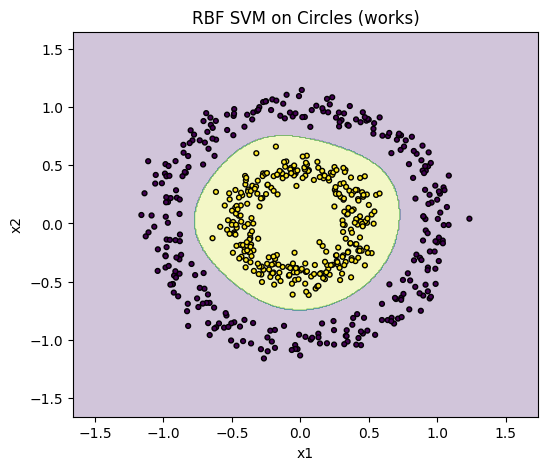

In [ ]:
# Linear SVM on moons
lin_moons = LinearSVC(C=1.0, dual="auto", random_state=0)
lin_moons.fit(X_moons, y_moons)
plot_decision_regions(lin_moons, X_moons, y_moons, title="Linear SVM on Moons (fails)")

# RBF SVM on moons
rbf_moons = SVC(kernel="rbf", C=10.0, gamma=1.0)
rbf_moons.fit(X_moons, y_moons)
plot_decision_regions(rbf_moons, X_moons, y_moons, title="RBF SVM on Moons (works)")

# Linear vs RBF on circles
lin_circ = LinearSVC(C=1.0, dual="auto", random_state=0)
lin_circ.fit(X_circ, y_circ)
plot_decision_regions(lin_circ, X_circ, y_circ, title="Linear SVM on Circles (fails)")

rbf_circ = SVC(kernel="rbf", C=10.0, gamma=2.0)
rbf_circ.fit(X_circ, y_circ)
plot_decision_regions(rbf_circ, X_circ, y_circ, title="RBF SVM on Circles (works)")


## 4) Animation: sweep \(\gamma\) for RBF to show bias–variance
This animates the decision boundary while we vary \(\gamma\) (holding `C` fixed). Small \(\gamma\) ⇒ smoother, large \(\gamma\) ⇒ wiggly/overfit.

> **Tip:** If animation is heavy, reduce `gammas` length or grid resolution.

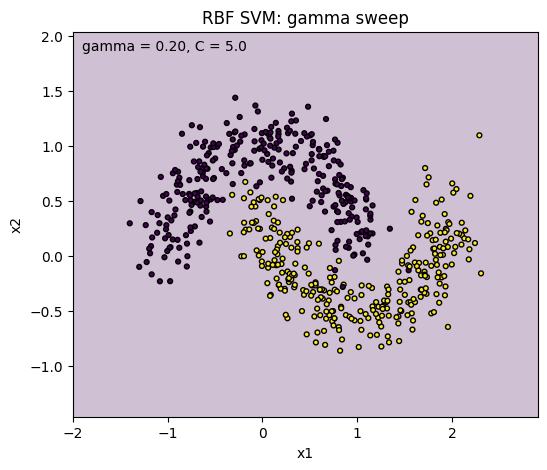

In [ ]:
X, y = X_moons, y_moons
x1min, x1max = X[:,0].min()-0.6, X[:,0].max()+0.6
x2min, x2max = X[:,1].min()-0.6, X[:,1].max()+0.6
xx1, xx2 = np.meshgrid(np.linspace(x1min, x1max, 260),
                       np.linspace(x2min, x2max, 260))
grid = np.c_[xx1.ravel(), xx2.ravel()]

gammas = np.linspace(0.2, 3.0, 40)  # 40 frames
C_val = 5.0

fig, ax = plt.subplots()
sc = ax.scatter(X[:,0], X[:,1], c=y, s=12, edgecolor='k')
ax.set_xlim(x1min, x1max); ax.set_ylim(x2min, x2max)
ax.set_title("RBF SVM: gamma sweep")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
im = ax.imshow(np.zeros_like(xx1), origin='lower', extent=(x1min,x1max,x2min,x2max), alpha=0.25, aspect='auto')
txt = ax.text(0.02, 0.98, "", transform=ax.transAxes, va='top')

def frame(i):
    g = gammas[i]
    clf = SVC(kernel='rbf', C=C_val, gamma=g)
    clf.fit(X, y)
    Z = clf.predict(grid).reshape(xx1.shape)
    im.set_data(Z)
    txt.set_text(f"gamma = {g:.2f}, C = {C_val}")
    return (im, txt)

ani = FuncAnimation(fig, frame, frames=len(gammas), interval=150, blit=True)
plt.show()

# Optional save (uncomment if you have ffmpeg/pillow):
from matplotlib.animation import PillowWriter
ani.save('rbf_gamma_sweep.gif', writer=PillowWriter(fps=10))


## 5) Explicit polynomial map example (degree 2)
We **construct** a 2D→3D mapping by hand:
\[ \phi(x_1,x_2) = (x_1^2, \sqrt{2}\,x_1x_2, x_2^2) \]
Then fit a **linear** SVM in this 3D feature space to separate the concentric circles.

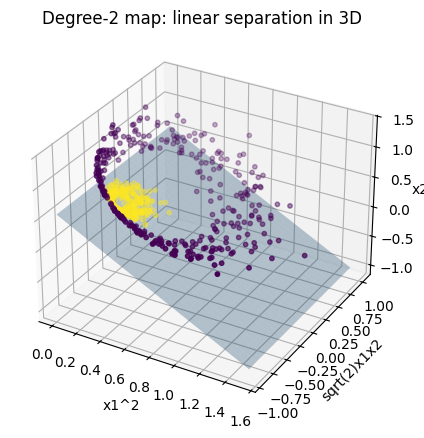

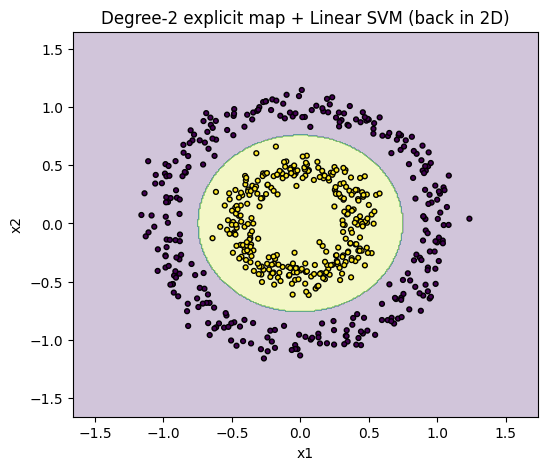

In [ ]:
def phi_deg2(X):
    x1 = X[:,0]
    x2 = X[:,1]
    return np.c_[x1**2, np.sqrt(2.0)*x1*x2, x2**2]

X3 = phi_deg2(X_circ)

# Linear SVM in 3D feature space
lin3 = LinearSVC(C=1.0, dual="auto", random_state=0)
lin3.fit(X3, y_circ)

# Plot 3D points and the separating plane
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:,0], X3[:,1], X3[:,2], c=y_circ, s=10)
ax.set_title("Degree-2 map: linear separation in 3D")
ax.set_xlabel("x1^2"); ax.set_ylabel("sqrt(2)x1x2"); ax.set_zlabel("x2^2")

# draw a plane w·z + b = 0 in (z1,z2,z3) space
w = lin3.coef_[0]; b = lin3.intercept_[0]
z1 = np.linspace(X3[:,0].min(), X3[:,0].max(), 30)
z2 = np.linspace(X3[:,1].min(), X3[:,1].max(), 30)
Z1, Z2 = np.meshgrid(z1, z2)
eps = 1e-12
if abs(w[2]) < 1e-9:
    Z3 = np.full_like(Z1, np.nan)
else:
    Z3 = (-b - w[0]*Z1 - w[1]*Z2) / (w[2] + eps)
ax.plot_surface(Z1, Z2, Z3, alpha=0.3)
plt.show()

# Bring decision back to 2D grid to visualize regions
x1min, x1max = X_circ[:,0].min()-0.5, X_circ[:,0].max()+0.5
x2min, x2max = X_circ[:,1].min()-0.5, X_circ[:,1].max()+0.5
xx1, xx2 = np.meshgrid(np.linspace(x1min, x1max, 350), np.linspace(x2min, x2max, 350))
grid = np.c_[xx1.ravel(), xx2.ravel()]
grid3 = phi_deg2(grid)
Z = lin3.predict(grid3).reshape(xx1.shape)

plt.figure()
plt.contourf(xx1, xx2, Z, alpha=0.25)
plt.scatter(X_circ[:,0], X_circ[:,1], c=y_circ, s=12, edgecolor='k')
plt.title("Degree-2 explicit map + Linear SVM (back in 2D)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


## 6) Quick tuning with GridSearchCV (RBF)
A small search to find good `C` and `gamma` values.

Best params: {'C': 5, 'gamma': 0.5}


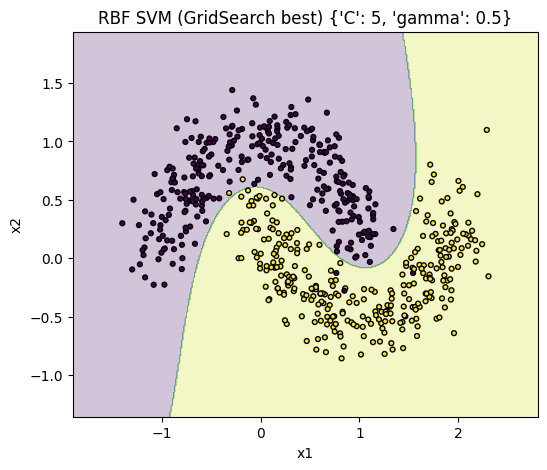

In [ ]:
param_grid = {"C": [0.5, 1, 5, 10], "gamma": [0.2, 0.5, 1.0, 2.0]}
clf = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=3, n_jobs=-1)
clf.fit(X_moons, y_moons)
print("Best params:", clf.best_params_)
best = clf.best_estimator_
plot_decision_regions(best, X_moons, y_moons, title=f"RBF SVM (GridSearch best) {clf.best_params_}")


### Talking points for class
- **Kernel trick** = compute inner products of a hidden feature map via `K(x, x')` without building that map explicitly.
- **Linear** fails on moons/circles; **RBF** works by measuring **local similarity** (Gaussian) and acting like a linear separator in a high-/infinite-dimensional space.
- **\(\gamma\)** controls how *local* similarity is: small = smoother decision; large = wiggly.
- **\(C\)** controls margin vs error tradeoff (as in soft-margin SVM).